In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    GMSHtools,
    FEMModel,
    plot_gmsh_mesh,
    globalParameters,
)
import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)



  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. Jose Abell

  Version 1.2.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen
  
  ********* (>'-')> Ladruno4ever  *********



In [3]:
globalParameters['nDoF'] = 3
globalParameters['nDIM'] = 3

In [4]:
# General model parameters
output_file = 'wrench_extrude.msh'

In [5]:
# read mesh — node_map and system_nDof auto-generated
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (26320 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1       -46.1557        13.3333         0.0000
       2       -46.1557       -13.3333         0.0000
       3        45.5761       -11.0200         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (7 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
     256      1   'Support'
     257      1   'LoadBoundary'
     252      2   'Cabeza_5mm_der'
     253      2   'Cabeza_5mm_izq'
     254      2   'Mango_3mm'
     255      2   'Mango_1_6mm'
     364      3   'solido'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (7 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------

In [6]:
# plot_gmsh_mesh(mesh,
#                show_node_labels    = False,
#                show_element_labels = False,
#                show_node_points    = False,
#                view_3d             = True, elev=45, azim=-45,
#                figsize             = (12, 8))

In [7]:
load_dictionary = {
                257:   {'value': 4, 'direction': '-y'},     
}



In [8]:
model = FEMModel(
    mesh                = mesh,
    section_dictionary  = {},
    restrain_dictionary = {},
    load_dictionary     = load_dictionary,
    element_class_map   = None,       # OpenSees only
    analysis_type       = '3D',
    consistent_loads    = False,
)


  FEM MODEL SUMMARY
--------------------------------------------------------------------------------
  Analysis type    : 3D
  Nodes            : 26320
  system_nDof      : 78960
  Elements         : None (OpenSees)
  Steps FEM        : 0
  Steps OpenSees   : 0

  --- Sections ---

  --- Restrained nodes ---

  --- Loaded nodes (dim=0) ---

  --- Load vector ---
  Non-zero DOFs in F_load : 35
  Total applied force     : -51.1230 (x)  -45.4426 (y)
--------------------------------------------------------------------------------



In [9]:
# Mesh diagnostics
model.check_mesh()


  MESH DIAGNOSTICS
--------------------------------------------------------------------------------
  Nodes            : 26320
  system_nDof      : 78960
  Elements         : None (OpenSees)
  Physical groups  : 7

  --- Orphan nodes ---
  Removed 3 orphan nodes — node_map rebuilt.

  --- Physical groups ---
      ID   Dim  Name                    Elements     Nodes  Section
  ------  ----  --------------------  ----------  --------  ----------
     256     1  Support                       50        52  N/A
     257     1  LoadBoundary                  34        35  N/A
     252     2  Cabeza_5mm_der              2178      1175  MISSING
     253     2  Cabeza_5mm_izq              2223      1210  MISSING
     254     2  Mango_3mm                   2965      1750  MISSING
     255     2  Mango_1_6mm                 1882      1035  MISSING
     364     3  solido                    109130     26317  MISSING

  --- Restrained nodes ---
     Tag             x             y  Condition
  ----

## Opensees

In [10]:
import openseespy.opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder', '-ndm', 3, '-ndf', 3)


In [11]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y , z)

In [12]:
# Boundary conditions
fixed_nodes = set()
for tag in mesh.physical_groups['Support'].nodes:
    if tag not in fixed_nodes:
        fixed_nodes.add(tag)
        # ops.fix(tag, 1, 1, 1, 1, 1, 1)
        ops.fix(tag, 1, 1, 1)

In [13]:
# Material
E = 3500      
nu = 0.36     
ops.nDMaterial('ElasticIsotropic', 1, E, nu)


In [14]:
# Elements
group = mesh.physical_groups['solido'].elements
for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
    n1, n2, n3, n4 = conn
    ops.element('FourNodeTetrahedron', elem_tag, n1, n2, n3, n4, 1)

In [15]:
# opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [16]:
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)

for tag, force in model.F_nodal.items():
    if np.any(np.abs(force) > 0):
        ops.load(tag, *force.tolist())

In [17]:
NstepGravity = 10
DGravity     = 1 / NstepGravity

ops.system("SparseSYM")
ops.numberer("RCM") 
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity)
ops.test("NormUnbalance", 1.0e-6, 100, 0)
ops.algorithm("Newton")
ops.analysis("Static")

# for step in range(NstepGravity):
#     ops.analyze(1)
#     model.set_results_opensees(ops, step=step)

ops.analyze(NstepGravity)
# save last step
model.set_results_opensees(ops, step=0, time=1.0)

FEMResult(step=0, time=1.0000)

In [18]:
# Static results in gmsh — last step
model.plot2gmsh(
    step           = -1,
    source         = 'opensees',
    disp_factor    = 2,
    show_disp      = True,
    show_loads     = True,
    show_reactions = True,
    show_stress    = True,
    show_strain    = True,
    show_vm        = True,
    show_averaged  = True,
)

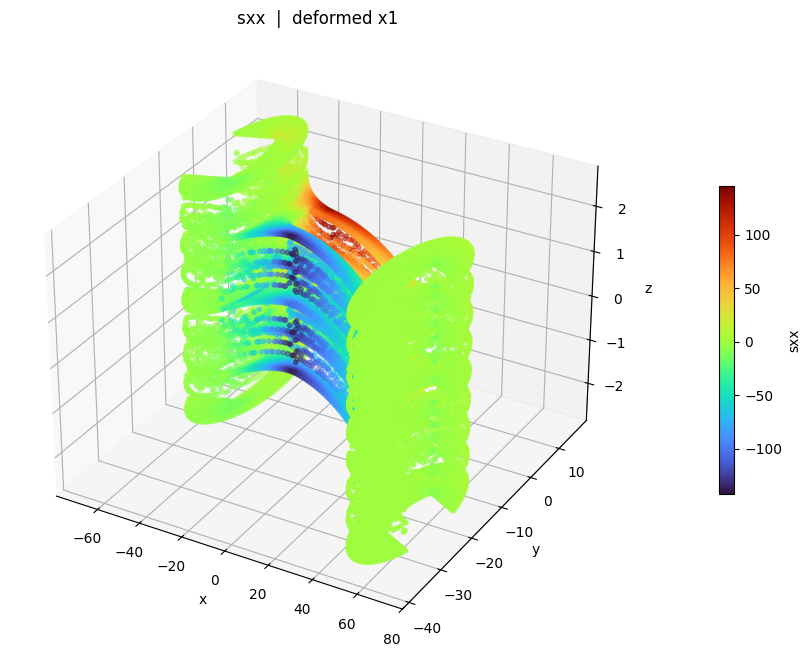

In [24]:
# Plot field
model.plot_field(
    component           = 'sxx',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'opensees',
    step                = -1,
    # result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 1,
    cmap                = 'turbo',
    # show_element_edges  = True,
    # show_supports       = True,
    figsize             = (12, 8),
)